<a href="https://colab.research.google.com/github/madikabhavana-collab/ores5160-2026/blob/main/EDA_US__Chronic_Disease_Indicators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('U.S._Chronic_Disease_Indicators_20260311.csv')
df.head()

/tmp/ipykernel_1665/550344877.py:1: DtypeWarning: Columns (10,11,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('U.S._Chronic_Disease_Indicators_20260311.csv')


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


In [3]:
df.shape

(309215, 34)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309215 entries, 0 to 309214
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  309215 non-null  int64  
 1   YearEnd                    309215 non-null  int64  
 2   LocationAbbr               309215 non-null  object 
 3   LocationDesc               309215 non-null  object 
 4   DataSource                 309215 non-null  object 
 5   Topic                      309215 non-null  object 
 6   Question                   309215 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              309215 non-null  object 
 9   DataValueType              309215 non-null  object 
 10  DataValue                  209196 non-null  object 
 11  DataValueAlt               209196 non-null  object 
 12  DataValueFootnoteSymbol    101716 non-null  object 
 13  DataValueFootnote          10

In [5]:
df['Topic'].unique()

array(['Health Status', 'Cancer', 'Diabetes', 'Sleep', 'Immunization',
       'Nutrition, Physical Activity, and Weight Status', 'Oral Health',
       'Arthritis', 'Asthma', 'Cardiovascular Disease', 'Disability',
       'Mental Health', 'Tobacco', 'Alcohol',
       'Chronic Obstructive Pulmonary Disease',
       'Social Determinants of Health', 'Cognitive Health and Caregiving',
       'Chronic Kidney Disease', 'Maternal Health'], dtype=object)

In [6]:
diabetes = df[df['Topic'] == 'Diabetes']
diabetes.shape

(17318, 34)

In [7]:
diabetes['Question'].unique()

array(['Diabetic ketoacidosis mortality among all people, underlying or contributing cause',
       'Diabetes among adults',
       'Gestational diabetes among women with a recent live birth',
       'Diabetes mortality among all people, underlying or contributing cause'],
      dtype=object)

In [8]:
diabetes_adults = diabetes[diabetes['Question'] == 'Diabetes among adults']
diabetes_adults.shape

(5060, 34)

In [9]:
diabetes_adults['DataValue'] = pd.to_numeric(diabetes_adults['DataValue'], errors='coerce')
diabetes_adults = diabetes_adults.dropna(subset=['DataValue'])

/tmp/ipykernel_1665/1920595770.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diabetes_adults['DataValue'] = pd.to_numeric(diabetes_adults['DataValue'], errors='coerce')


In [10]:
diabetes_adults['DataValue'].describe()

,DataValue
count,3540.000000
mean,12.205706
std,5.008711
min,1.400000
25%,9.100000
50%,11.500000
75%,14.800000
max,47.000000


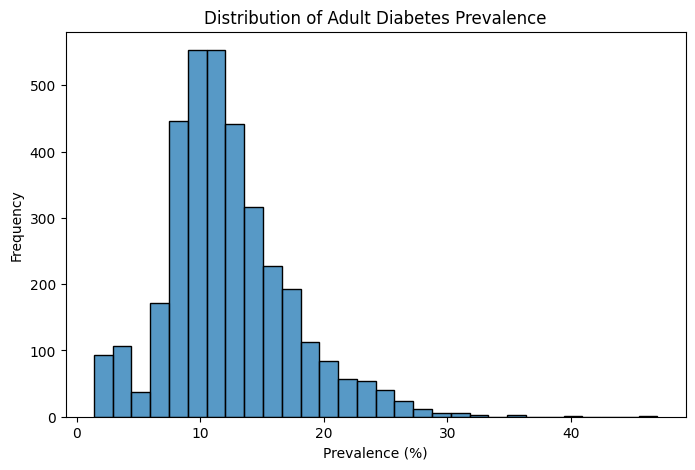

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(diabetes_adults['DataValue'], bins=30)

plt.title("Distribution of Adult Diabetes Prevalence")
plt.xlabel("Prevalence (%)")
plt.ylabel("Frequency")

plt.show()

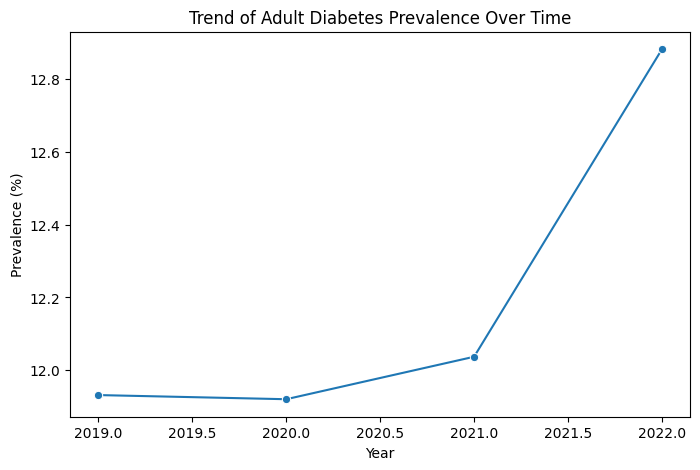

In [12]:
year_avg = diabetes_adults.groupby('YearStart')['DataValue'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=year_avg, x='YearStart', y='DataValue', marker='o')

plt.title("Trend of Adult Diabetes Prevalence Over Time")
plt.xlabel("Year")
plt.ylabel("Prevalence (%)")

plt.show()

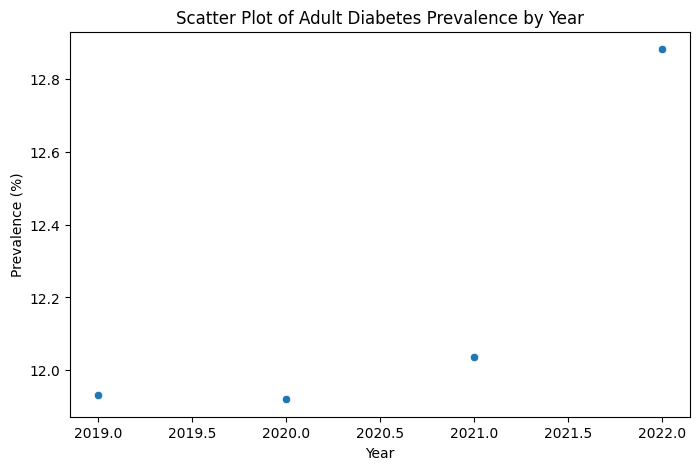

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=year_avg, x='YearStart', y='DataValue')

plt.title("Scatter Plot of Adult Diabetes Prevalence by Year")
plt.xlabel("Year")
plt.ylabel("Prevalence (%)")

plt.show()

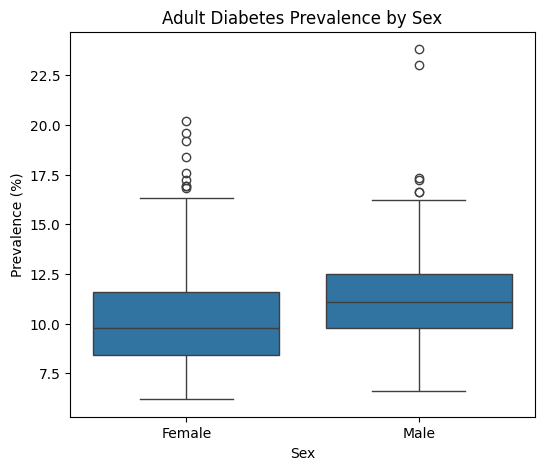

In [14]:
sex_data = diabetes_adults[diabetes_adults['StratificationCategory1'] == 'Sex']

plt.figure(figsize=(6,5))
sns.boxplot(data=sex_data, x='Stratification1', y='DataValue')

plt.title("Adult Diabetes Prevalence by Sex")
plt.xlabel("Sex")
plt.ylabel("Prevalence (%)")

plt.show()

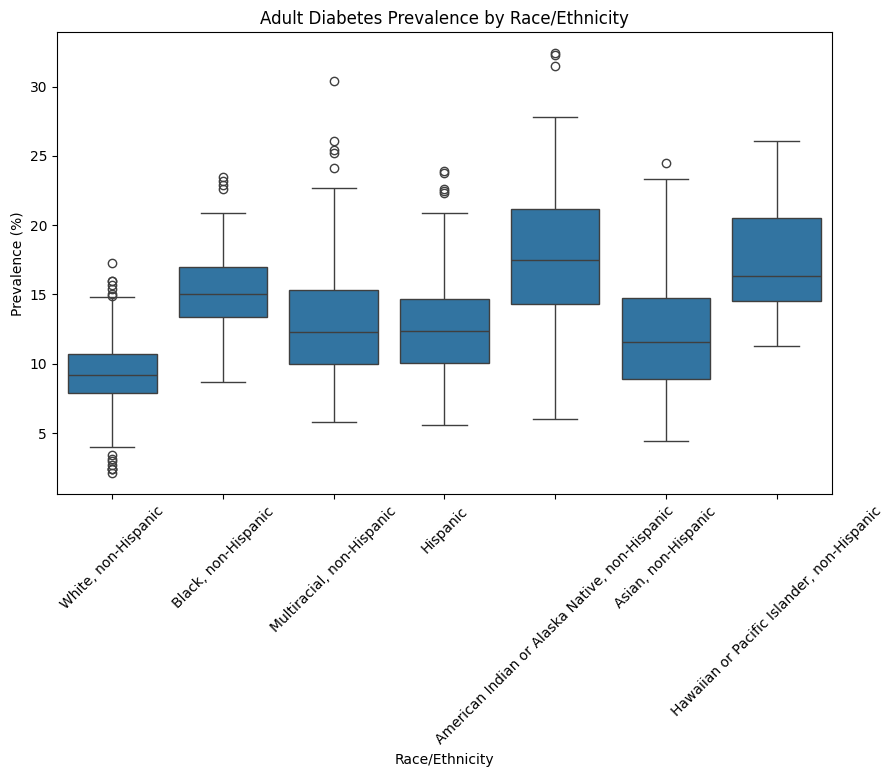

In [15]:
race_data = diabetes_adults[diabetes_adults['StratificationCategory1'] == 'Race/Ethnicity']

plt.figure(figsize=(10,6))
sns.boxplot(data=race_data, x='Stratification1', y='DataValue')

plt.title("Adult Diabetes Prevalence by Race/Ethnicity")
plt.xticks(rotation=45)

plt.xlabel("Race/Ethnicity")
plt.ylabel("Prevalence (%)")

plt.show()